# GMMVAE — 2D UMAP Cluster Visualization

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns

UMAP_PATH = 'output_gmmvae/embedding_2d_umap.csv'
PROBS_PATH = 'output_gmmvae/cluster_probabilities.npy'

## 1. Load Data

In [12]:
df = pd.read_csv(UMAP_PATH)
print(f'Samples: {len(df)}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nCluster counts:')
print(df['cluster'].value_counts().sort_index())
df.head()

Samples: 2801
Columns: ['sample', 'dim1', 'dim2', 'cluster']

Cluster counts:
cluster
0       1
1      70
2     152
3     262
4     772
5     239
6     281
7      57
8      26
9      43
10     39
11    244
12    179
13    336
14    100
Name: count, dtype: int64


,sample,dim1,dim2,cluster
0,SAMPLE 1,12.010082,-0.151519,7
1,SAMPLE 2,8.221077,1.322747,14
2,SAMPLE 3,8.536789,1.187312,14
3,SAMPLE 4,8.064356,1.218112,14
4,SAMPLE 5,8.566692,1.283884,14


In [4]:
clusters = sorted(df['cluster'].unique())
n_clusters = len(clusters)
print(f'Active clusters ({n_clusters}): {clusters}')

# Assign a consistent color per cluster
palette = sns.color_palette('tab20', n_clusters) if n_clusters <= 20 else sns.color_palette('husl', n_clusters)
color_map = {c: palette[i] for i, c in enumerate(clusters)}
colors = df['cluster'].map(color_map).tolist()

Active clusters (8): [np.int64(1), np.int64(8), np.int64(12), np.int64(19), np.int64(35), np.int64(40), np.int64(59), np.int64(71)]


## 2. Basic UMAP Scatter

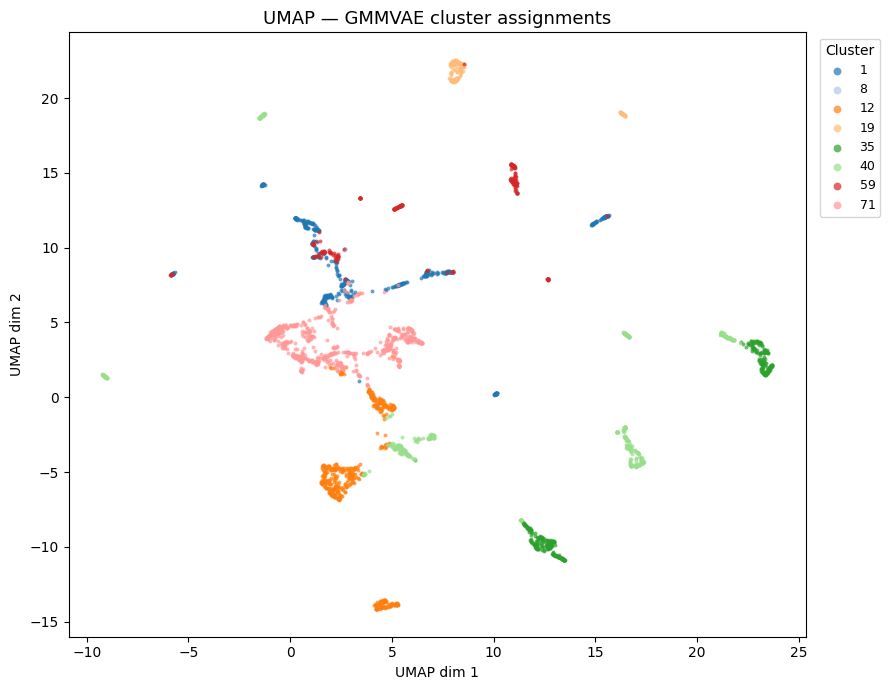

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))

for c in clusters:
    mask = df['cluster'] == c
    ax.scatter(
        df.loc[mask, 'dim1'], df.loc[mask, 'dim2'],
        c=[color_map[c]], s=8, alpha=0.7, linewidths=0, label=str(c)
    )

ax.set_title('UMAP — GMMVAE cluster assignments', fontsize=13)
ax.set_xlabel('UMAP dim 1')
ax.set_ylabel('UMAP dim 2')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left',
          markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig('output_gmmvae/umap_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Cluster Size Bar Chart

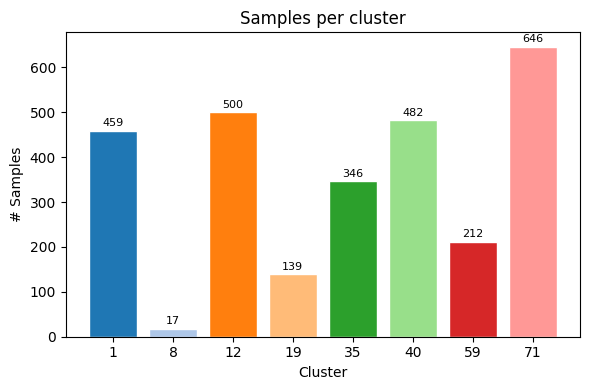

In [6]:
counts = df['cluster'].value_counts().sort_index()
bar_colors = [color_map[c] for c in counts.index]

fig, ax = plt.subplots(figsize=(max(6, n_clusters * 0.7), 4))
bars = ax.bar(counts.index.astype(str), counts.values, color=bar_colors, edgecolor='white')
ax.bar_label(bars, fontsize=8, padding=2)
ax.set_title('Samples per cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('# Samples')
plt.tight_layout()
plt.savefig('output_gmmvae/cluster_sizes.png', dpi=150)
plt.show()

## 4. Cluster Centroids on UMAP

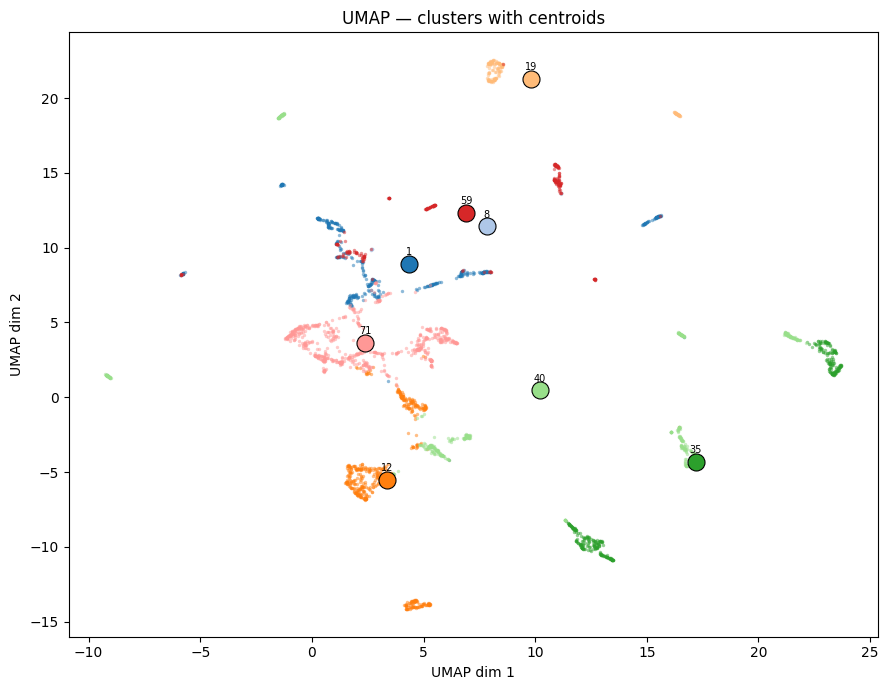

In [7]:
centroids = df.groupby('cluster')[['dim1', 'dim2']].mean()

fig, ax = plt.subplots(figsize=(9, 7))

for c in clusters:
    mask = df['cluster'] == c
    ax.scatter(
        df.loc[mask, 'dim1'], df.loc[mask, 'dim2'],
        c=[color_map[c]], s=6, alpha=0.5, linewidths=0
    )

for c in clusters:
    cx, cy = centroids.loc[c, 'dim1'], centroids.loc[c, 'dim2']
    ax.scatter(cx, cy, c=[color_map[c]], s=150, edgecolors='black', linewidths=0.8, zorder=5)
    ax.annotate(str(c), (cx, cy), fontsize=7, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

ax.set_title('UMAP — clusters with centroids')
ax.set_xlabel('UMAP dim 1')
ax.set_ylabel('UMAP dim 2')
plt.tight_layout()
plt.savefig('output_gmmvae/umap_centroids.png', dpi=150)
plt.show()

## 5. Assignment Confidence (max cluster probability)

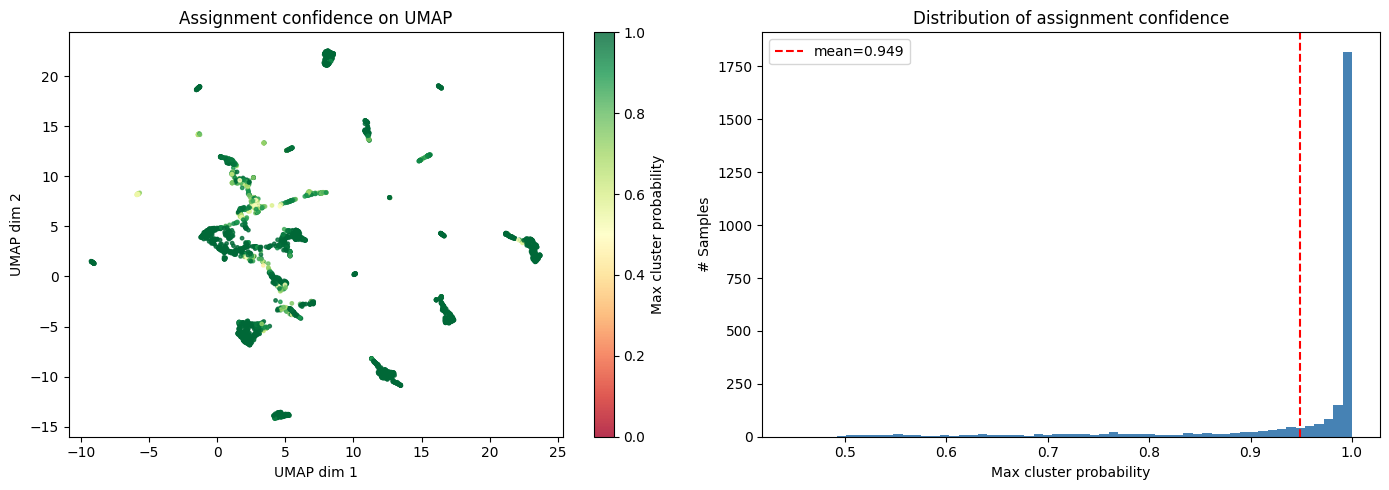

Confidence — mean: 0.9490, min: 0.4461, max: 1.0000
Samples with confidence > 0.9 : 2357 (84.1%)
Samples with confidence < 0.5 : 3 (0.1%)


In [8]:
import os

if os.path.exists(PROBS_PATH):
    probs = np.load(PROBS_PATH)          # (n_samples, n_clusters_total)
    confidence = probs.max(axis=1)       # highest probability for assigned cluster
    df['confidence'] = confidence

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter colored by confidence
    sc = axes[0].scatter(
        df['dim1'], df['dim2'],
        c=df['confidence'], cmap='RdYlGn', s=6, alpha=0.8,
        vmin=0, vmax=1
    )
    plt.colorbar(sc, ax=axes[0], label='Max cluster probability')
    axes[0].set_title('Assignment confidence on UMAP')
    axes[0].set_xlabel('UMAP dim 1')
    axes[0].set_ylabel('UMAP dim 2')

    # Confidence histogram
    axes[1].hist(confidence, bins=60, color='steelblue', edgecolor='none')
    axes[1].axvline(confidence.mean(), color='red', linestyle='--',
                    label=f'mean={confidence.mean():.3f}')
    axes[1].set_title('Distribution of assignment confidence')
    axes[1].set_xlabel('Max cluster probability')
    axes[1].set_ylabel('# Samples')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('output_gmmvae/umap_confidence.png', dpi=150)
    plt.show()

    print(f'Confidence — mean: {confidence.mean():.4f}, min: {confidence.min():.4f}, max: {confidence.max():.4f}')
    print(f'Samples with confidence > 0.9 : {(confidence > 0.9).sum()} ({(confidence > 0.9).mean()*100:.1f}%)')
    print(f'Samples with confidence < 0.5 : {(confidence < 0.5).sum()} ({(confidence < 0.5).mean()*100:.1f}%)')
else:
    print(f'{PROBS_PATH} not found — skipping confidence plots.')

## 6. Per-Cluster Confidence Box Plot

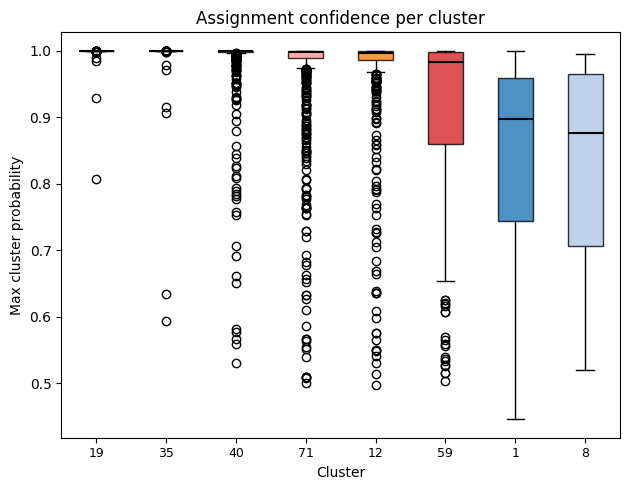

In [9]:
if 'confidence' in df.columns:
    order = df.groupby('cluster')['confidence'].median().sort_values(ascending=False).index.tolist()
    box_colors = [color_map[c] for c in order]

    fig, ax = plt.subplots(figsize=(max(6, n_clusters * 0.8), 5))
    bp = ax.boxplot(
        [df.loc[df['cluster'] == c, 'confidence'].values for c in order],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1.5)
    )
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    ax.set_xticklabels([str(c) for c in order], fontsize=9)
    ax.set_title('Assignment confidence per cluster')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Max cluster probability')
    plt.tight_layout()
    plt.savefig('output_gmmvae/confidence_per_cluster.png', dpi=150)
    plt.show()
else:
    print('Confidence data not available — run cell 5 first.')

## 7. Per-Cluster Density (KDE)

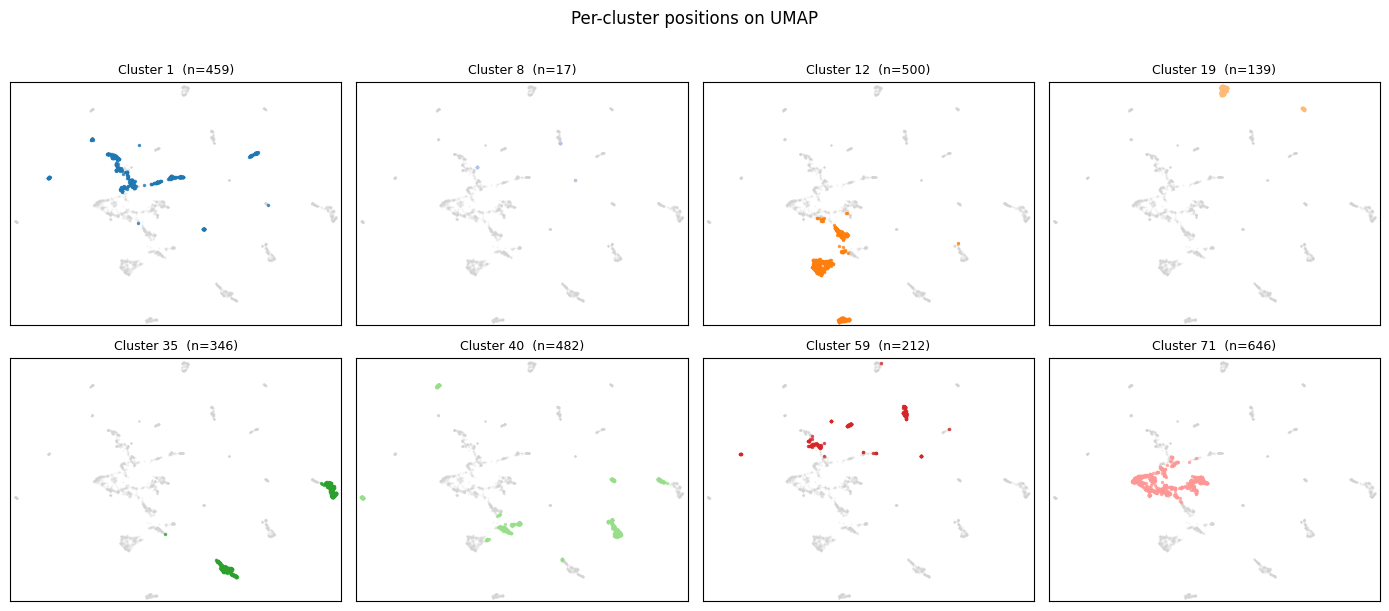

In [10]:
from scipy.stats import gaussian_kde

ncols = min(4, n_clusters)
nrows = int(np.ceil(n_clusters / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3))
axes = np.array(axes).ravel()

x_all, y_all = df['dim1'].values, df['dim2'].values
xlim = (x_all.min() - 0.5, x_all.max() + 0.5)
ylim = (y_all.min() - 0.5, y_all.max() + 0.5)

for i, c in enumerate(clusters):
    ax = axes[i]
    mask = df['cluster'] == c
    sub = df.loc[mask]
    # background (all samples)
    ax.scatter(x_all, y_all, s=2, c='lightgrey', alpha=0.3, linewidths=0)
    # cluster samples
    ax.scatter(sub['dim1'], sub['dim2'], s=6, c=[color_map[c]], alpha=0.8, linewidths=0)
    ax.set_title(f'Cluster {c}  (n={mask.sum()})', fontsize=9)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xticks([])
    ax.set_yticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Per-cluster positions on UMAP', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('output_gmmvae/umap_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()